In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
df = pd.read_csv("/content/cleaned_data.csv")
df

,CustomerID,Name,Age,Gender,City,JoinDate,PurchaseAmount,ProductCategory,Rating
0,118,Kiara Kumar,53.0,Female,Chennai,2024-11-01,2625.28,Furniture,1.2
1,107,Unknown,43.0,Female,Varanasi,2022-08-08,2954.49,Electronics,2.6
2,78,Saanvi Bose,45.0,Male,Hyderabad,2024-10-20,2984.16,Electronics,3.7
3,93,Aditya Rao,42.0,Male,Chennai,2021-10-07,1840.34,Groceries,1.0
4,18,Aadhya Singh,21.0,Male,Mumbai,2024-08-14,3871.82,Groceries,1.7
...,...,...,...,...,...,...,...,...,...
119,73,Aditya Bose,37.0,Female,Hyderabad,2022-10-09,3708.85,Groceries,3.9
120,69,Riya Rao,57.0,Female,Varanasi,2021-05-14,2763.77,Groceries,1.0
121,4,Arjun Iyer,40.0,Female,Bengaluru,2024-12-15,1664.05,Groceries,3.8
122,120,Meera Menon,33.0,Not Identified,Hyderabad,2022-03-31,2575.75,Electronics,1.3


In [8]:
df.shape

(124, 9)

In [14]:
# Statistical overview for numeric columns: Age, PurchaseAmount, Rating
stats_summary = df[["Age", "PurchaseAmount", "Rating"]].describe().round(2)
print("--- Descriptive Statistics ---")
print(stats_summary)

--- Descriptive Statistics ---
          Age  PurchaseAmount  Rating
count  124.00          124.00  124.00
mean    40.11         3406.15    2.94
std     11.98         8783.15    1.12
min     18.00          110.34    0.00
25%     32.75         2070.50    2.08
50%     40.00         2577.04    3.00
75%     50.00         3070.64    3.80
max     63.00        99999.99    5.00


Business Grouping & Aggregations

In [15]:
# Total and average revenue by product category
print("--- Sales by Product Category ---")
cat_sales = (
    df.groupby("ProductCategory")["PurchaseAmount"]
    .agg(
        Order_Count="count",
        Total_Revenue="sum",
        Average_Order="mean",
        Median_Order="median",
    )
    .round(2)
)
print(cat_sales)

# Customer distribution by city
print("\n--- Customer Count & Sales by City ---")
city_sales = (
    df.groupby("City")["PurchaseAmount"]
    .agg(Customers="count", Total_Sales="sum", Avg_Spend="mean")
    .round(2)
)
print(city_sales)

--- Sales by Product Category ---
                 Order_Count  Total_Revenue  Average_Order  Median_Order
ProductCategory                                                         
Books                     29       71616.64        2469.54       2304.29
Clothing                  21       63486.57        3023.17       2888.34
Electronics               19       52233.56        2749.13       2791.68
Furniture                 20       54044.21        2702.21       2662.16
Groceries                 31       74389.02        2399.65       2153.43
Other                      4      106592.97       26648.24       2329.35

--- Customer Count & Sales by City ---
           Customers  Total_Sales  Avg_Spend
City                                        
Bengaluru          8     20622.35    2577.79
Chennai           16     39085.70    2442.86
Delhi             18     48762.73    2709.04
Hyderabad         15     40714.28    2714.29
Kolkata           20     44197.20    2209.86
Mumbai            14     40

Total Sales by Product Category

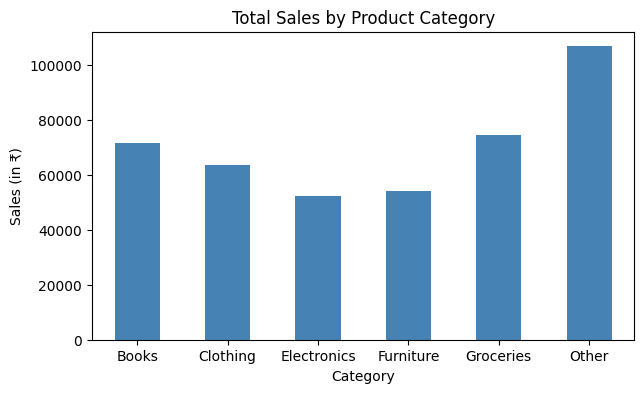

In [17]:
# Group by category and sum sales
category_sales = df.groupby('ProductCategory')['PurchaseAmount'].sum()

category_sales.plot(kind='bar', color='steelblue', figsize=(7, 4))

plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Sales (in ₹)")
plt.xticks(rotation=0)
plt.show()

Customer Age Distribution

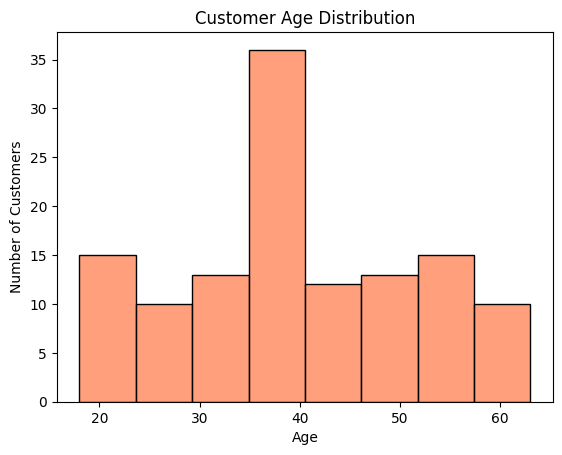

In [32]:
sns.histplot(df['Age'], bins='auto', color='coral', edgecolor='black')
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

Number of Customers in Each City

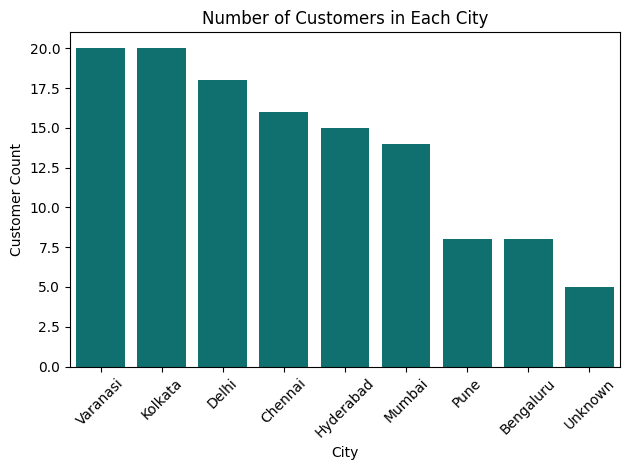

In [26]:
sns.countplot(
    data=df,
    x='City',
    order=df['City'].value_counts().index,  # Sorts bars from highest to lowest
    color='teal'
)

plt.title("Number of Customers in Each City")
plt.xlabel("City")
plt.ylabel("Customer Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Rating Breakdown

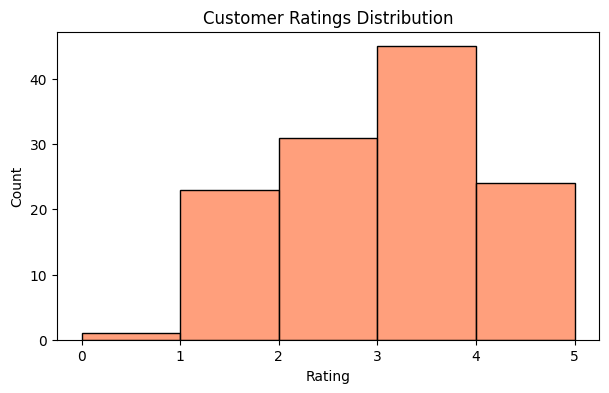

In [29]:
plt.figure(figsize=(7, 4))

# bins=5 automatically groups decimals into 5 clean, wide buckets
sns.histplot(df['Rating'], bins=5, color='coral', edgecolor='black')

plt.title("Customer Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()